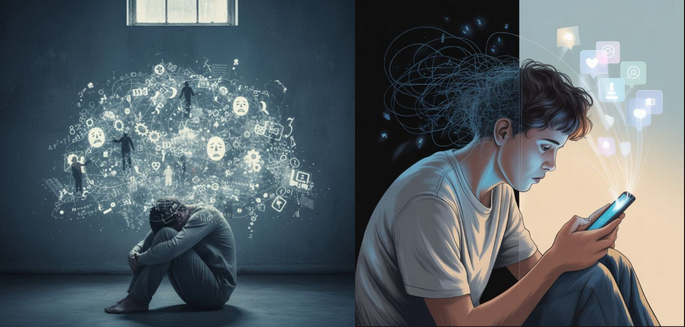



# Predicting Teen Mental Health Using Multiple <br> Machine Learning Models: Dealing with Imbalanced Data
***Author:** Salem Ali*

Hi everyone!

In this notebook, I'm diving into a really important topic: predicting teen mental health (specifically depression) based on their daily habits. We'll be looking at things like screen time, the social media platforms they use *(Tiktok, Instagram, both)*, sleep hours, and social interaction levels. 

## The Real Challenge Here
When I first explored this dataset, I noticed a massive challenge that we often face in real-world data: **it is highly imbalanced**. Out of about 1200 records, there are only around 31 cases of the target class (depression). 

If we just throw a standard machine learning model at this, it could easily hit 97%+ accuracy just by guessing "no depression" every single time! But obviously, that defeats the whole purpose of the project. 

## The Goal
My main focus isn't just to get a fake high accuracy score. I want to build a reliable model that actually learns the patterns to detect the minority class. Because of this, I'll be judging the models based on **Recall** and **F1-Score** instead of just basic Accuracy.

## My Workflow
Here is a quick breakdown of how I approached the problem:
1. **Careful Splitting:** I used `stratify` when splitting the data. This guarantees that the few rare depression cases are distributed fairly between the training and testing sets.
2. **Handling the Imbalance (SMOTE):** I used SMOTE to generate synthetic data for the minority class. *Crucial note: I made sure to apply SMOTE ONLY to the training data to prevent any data leakage into the test set!*
3. **Testing Models:** I started with a baseline Decision Tree, then moved on to stronger ensemble models like Random Forest and XGBoost to handle the complexity and avoid overfitting.

**If you have any feedback, suggestions, or ways I can improve this, please let me know in the comments. And if you find this notebook helpful, an upvote would be awesome!**



In [1]:
%pip install scikit-learn
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install xgboost
%pip install imblearn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,recall_score,precision_score,confusion_matrix,f1_score,ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE,BorderlineSMOTE,ADASYN
from sklearn.model_selection import GridSearchCV

# **Data Reading and Visualization**

In [3]:
# Read the Data 
df=pd.read_csv('data/Teen_Mental_Health_Dataset.csv')
df.head(7)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0


In [4]:
print('The DataSet Size : ',df.shape)
print('The max Null counts in the Data',df.isnull().sum().max())

The DataSet Size :  (1200, 13)
The max Null counts in the Data 0


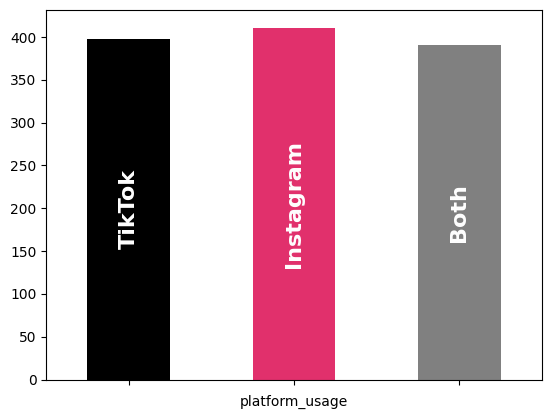

In [5]:
labels = ['TikTok', 'Instagram', 'Both']
ax = df['platform_usage'].value_counts().reindex(labels).plot.bar(color=['black','#E1306C','gray'])
ax.bar_label(ax.containers[0], labels=labels, label_type='center', color='white', rotation=90,fontsize=16, fontweight='bold')
ax.set_xticklabels([])
plt.show()

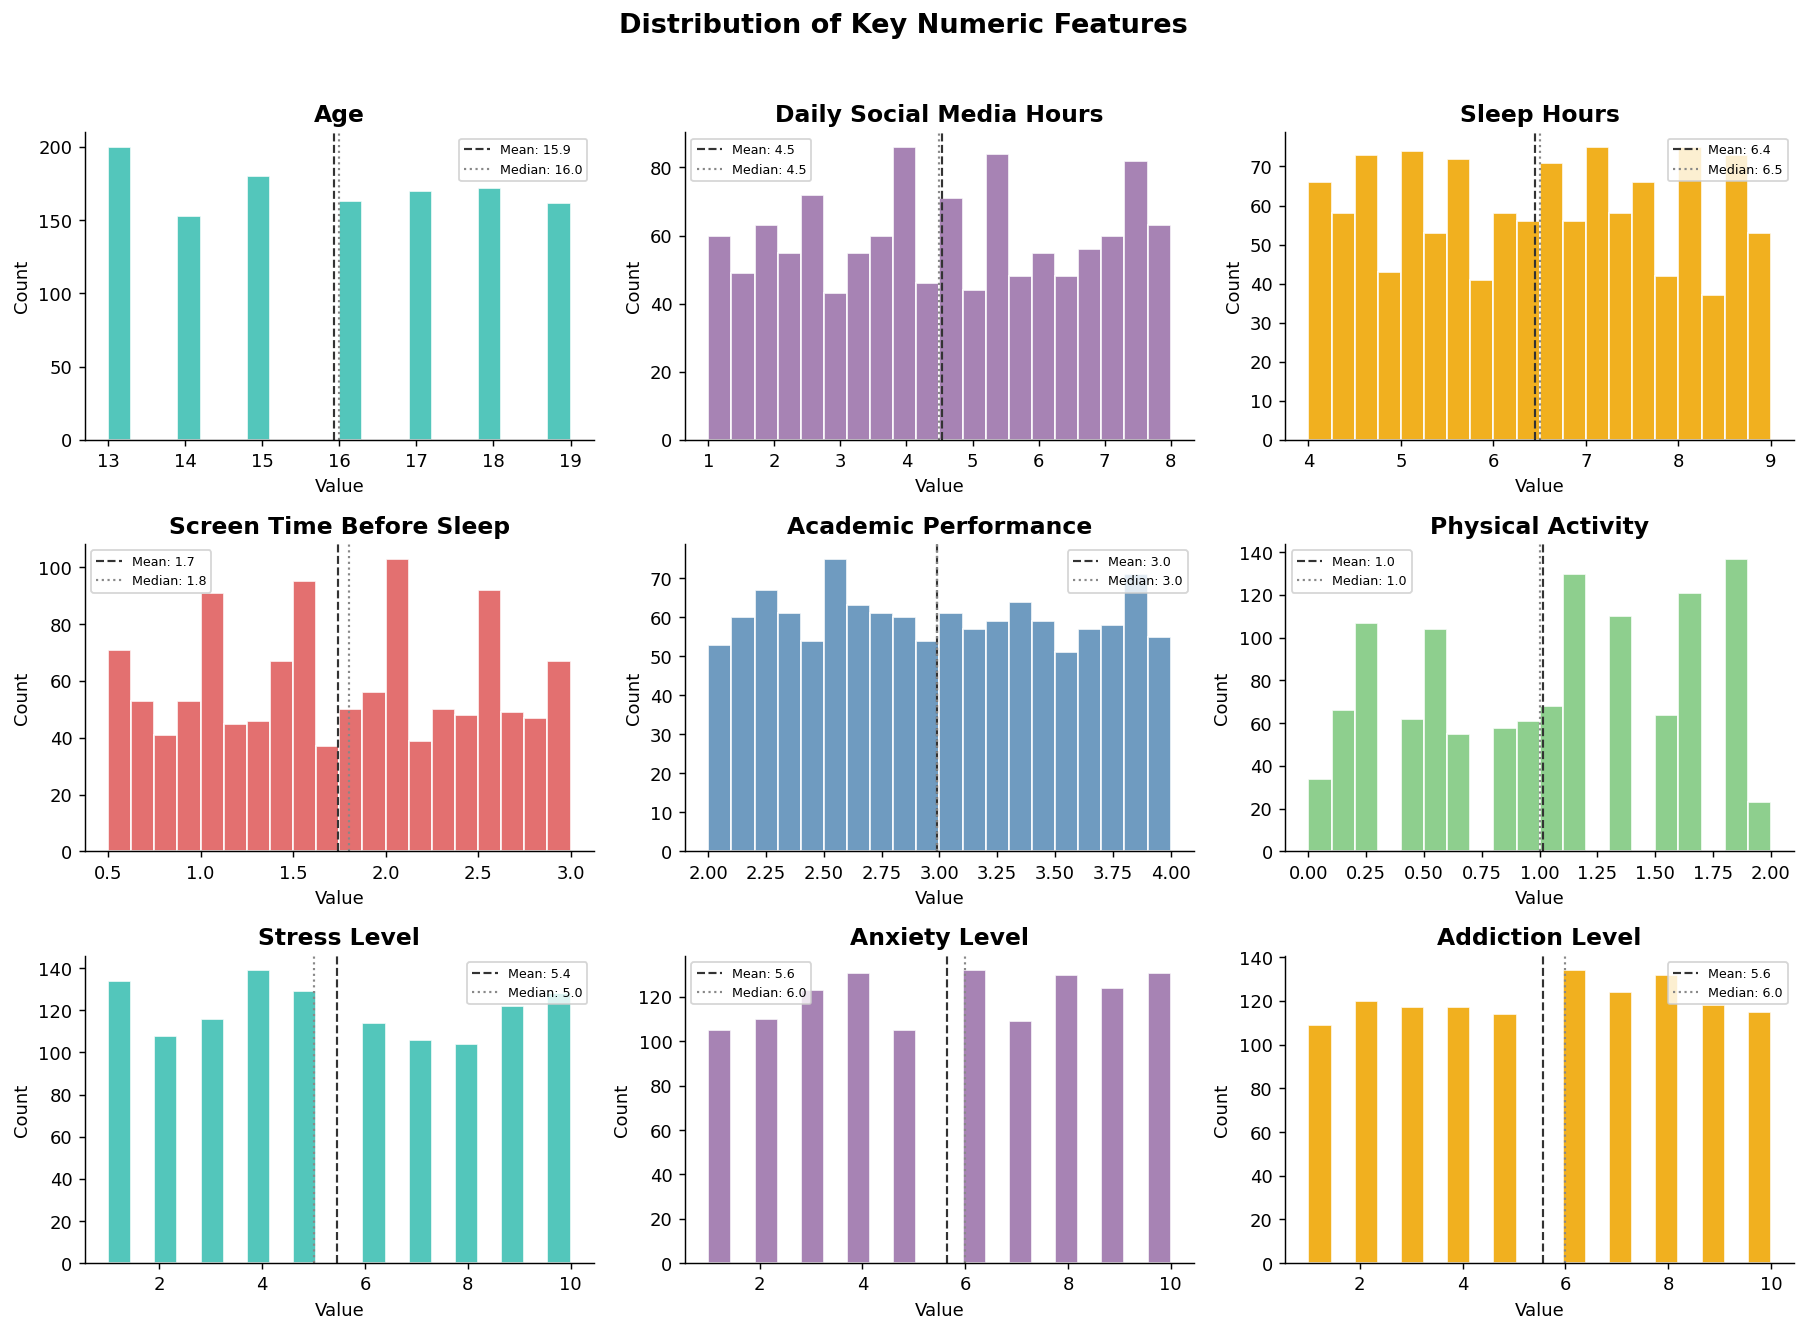

In [6]:
import warnings
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "figure.dpi": 130, "font.family": "DejaVu Sans"
})

num_cols = ["age", "daily_social_media_hours", "sleep_hours", "screen_time_before_sleep", 
            "academic_performance", "physical_activity", "stress_level", "anxiety_level", "addiction_level"]
colors = ["#3BBFB2", "#9B72AA", "#F0A500", "#E05C5C", "#5B8DB8", "#7FC97F"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle("Distribution of Key Numeric Features", fontsize=15, fontweight="bold", y=1.02)

for i, ax in enumerate(axes.flatten()):
    col = num_cols[i]
    data = df[col].dropna()
    ax.hist(data, bins=20, color=colors[i % len(colors)], edgecolor="white", alpha=0.88)
    ax.axvline(data.mean(), color="#333333", ls="--", lw=1.2, label=f"Mean: {data.mean():.1f}")
    ax.axvline(data.median(), color="#888888", ls=":", lw=1.2, label=f"Median: {data.median():.1f}")
    ax.set(title=col.replace("_", " ").title(), xlabel="Value", ylabel="Count")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("chart1_distributions.png", bbox_inches="tight")
plt.show()

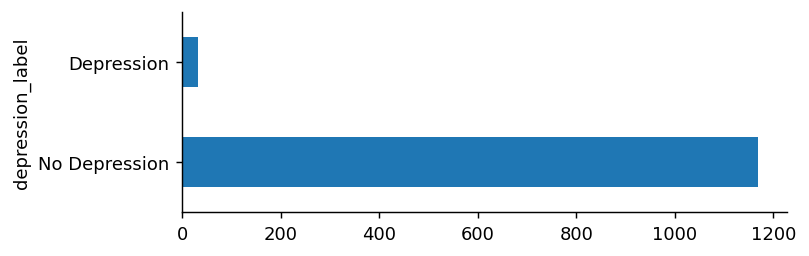

depression_label
0    1169
1      31
Name: count, dtype: int64


In [7]:
strlbl='depression_label' 
plt.figure(figsize=(6, 2))
df[ strlbl ].value_counts().rename(index={1:'Depression',0:'No Depression'}).plot.barh()
plt.show()
print(df[ strlbl ].value_counts()) 

In [8]:
df.dtypes

age                           int64
gender                          str
daily_social_media_hours    float64
platform_usage                  str
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level        str
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

In [9]:
print(df['social_interaction_level'].unique())
print(df['platform_usage'].unique())

<StringArray>
['low', 'high', 'medium']
Length: 3, dtype: str
<StringArray>
['Instagram', 'TikTok', 'Both']
Length: 3, dtype: str


# Preproceisng.
- FIll if there is missing values. 
- convert String to numbers

In [10]:
dfe=df.copy()
dfe['gender']=dfe['gender'].map({'male':1,'female':0})
dfe['social_interaction_level']=dfe['social_interaction_level'].map({'low':0, 'high':1, 'medium':2})
dfe['platform_usage']=dfe['platform_usage'].map({'Instagram':0 ,'TikTok':1, 'Both':2})

print(dfe.isnull().sum().max() , ', if 0 there is no null')

0 , if 0 there is no null


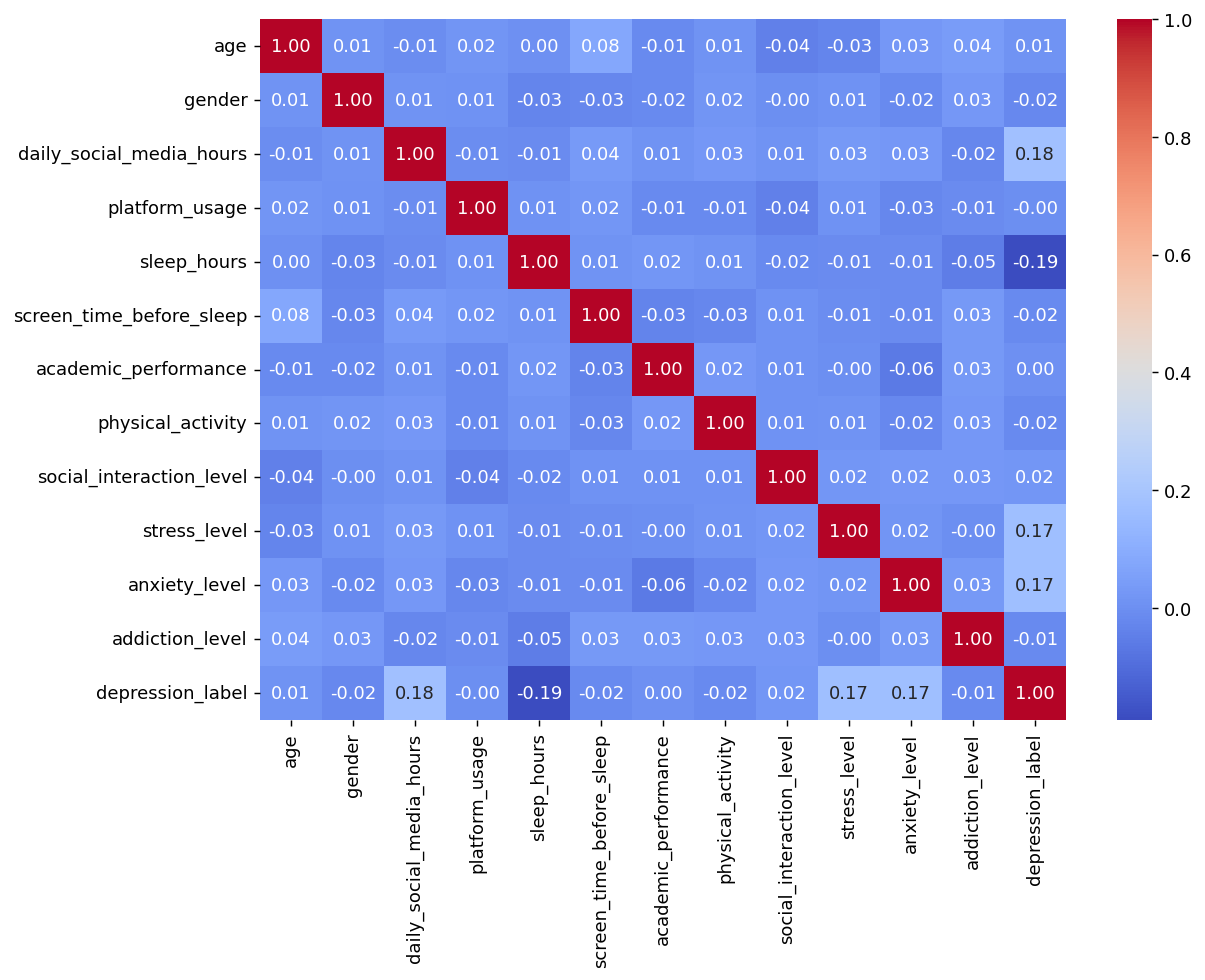

In [11]:
plt.figure(figsize=(10, 7))
sns.heatmap(dfe.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [12]:
Feature=dfe.drop([strlbl],axis=1)
Label=dfe[strlbl]
print('The DataSize: ', len(Label))

The DataSize:  1200


# ****Split The Data into Trainging and Testing****
 
* ****Select The Size of Training****
* ****Select The Size of Testing****


In [13]:
xtrain,xtest,ytrain,ytest=train_test_split( Feature,Label,
                                            test_size=0.2,
                                            # train_size=500,
                                            random_state=42,
                                            stratify=Label
                                           )

print('The Training Size: ', len(ytrain))
print('The Testing Size: ', len(ytest))
print('\nThe Test labels counts:')
print(ytest.value_counts())

The Training Size:  960
The Testing Size:  240

The Test labels counts:
depression_label
0    234
1      6
Name: count, dtype: int64


# ****Fix The imbalance Training Data Using SMOTE****

In [14]:

print('The Training DataSize Before SMOTE: ', len(ytrain))

#==================================================================== """

smote = SMOTETomek(random_state=42)
# smote = BorderlineSMOTE(random_state=42, k_neighbors=2)
# smote = ADASYN(random_state=42,n_neighbors=2)
xtrainsmote,ytrainsmote=smote.fit_resample(xtrain,ytrain)

#==================================================================== """

print('The Training DataSize After SMOTE: ', len(ytrainsmote))


The Training DataSize Before SMOTE:  960
The Training DataSize After SMOTE:  1870


#  ****Decision Tree Classifier****
* ** **Training the model using SMOTE training data**
* ** **Predict the answers**
* ** **Cheak The scores**
* ** **Display The Confiosn matrix**
* ** **Display The Features Importince**
* ** **Display The Tree**

 Time := 0.02  seconds


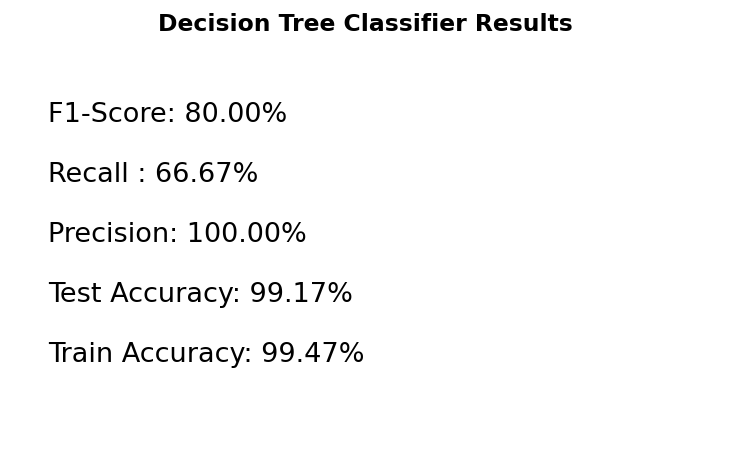

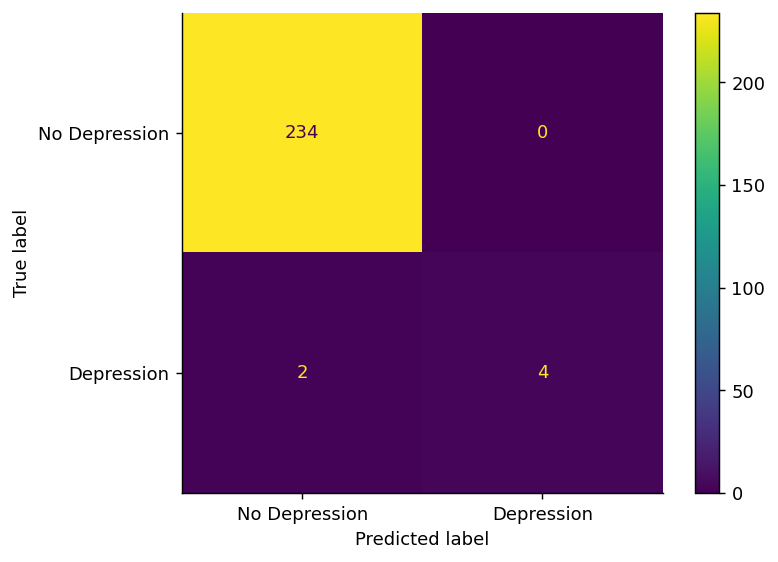

In [15]:
starttime=time.perf_counter()
modelD=DecisionTreeClassifier(
                              max_depth=4,
                              random_state=42,
                               min_samples_split=50,
                               min_samples_leaf=35
         )

"""

"""
# Train using SMOTE data
modelD.fit(xtrainsmote, ytrainsmote)

# Predictions
train_predictions = modelD.predict(xtrainsmote)
test_predictions = modelD.predict(xtest)



train_Accuracy = accuracy_score(ytrainsmote, train_predictions)
test_Accuracy = accuracy_score(ytest, test_predictions)

Recall = recall_score(ytest, test_predictions)
Precision = precision_score(ytest, test_predictions)
F11 = f1_score(ytest, test_predictions)
cm = confusion_matrix(ytest, test_predictions)




print(' Time :=',format(time.perf_counter()-starttime,'.2f'),' seconds')




# Print the result 

plt.figure(figsize=(7,4))
plt.axis('off')
plt.title('Decision Tree Classifier Results')
plt.text(0.05, 0.80, f"F1-Score: {F11 * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.65, f"Recall : {Recall * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.50, f"Precision: {Precision * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.35, f"Test Accuracy: {test_Accuracy * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.20, f"Train Accuracy: {train_Accuracy * 100:.2f}%", fontsize=15, ha='left')
plt.show() 

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Depression", "Depression"]
).plot()

plt.show()

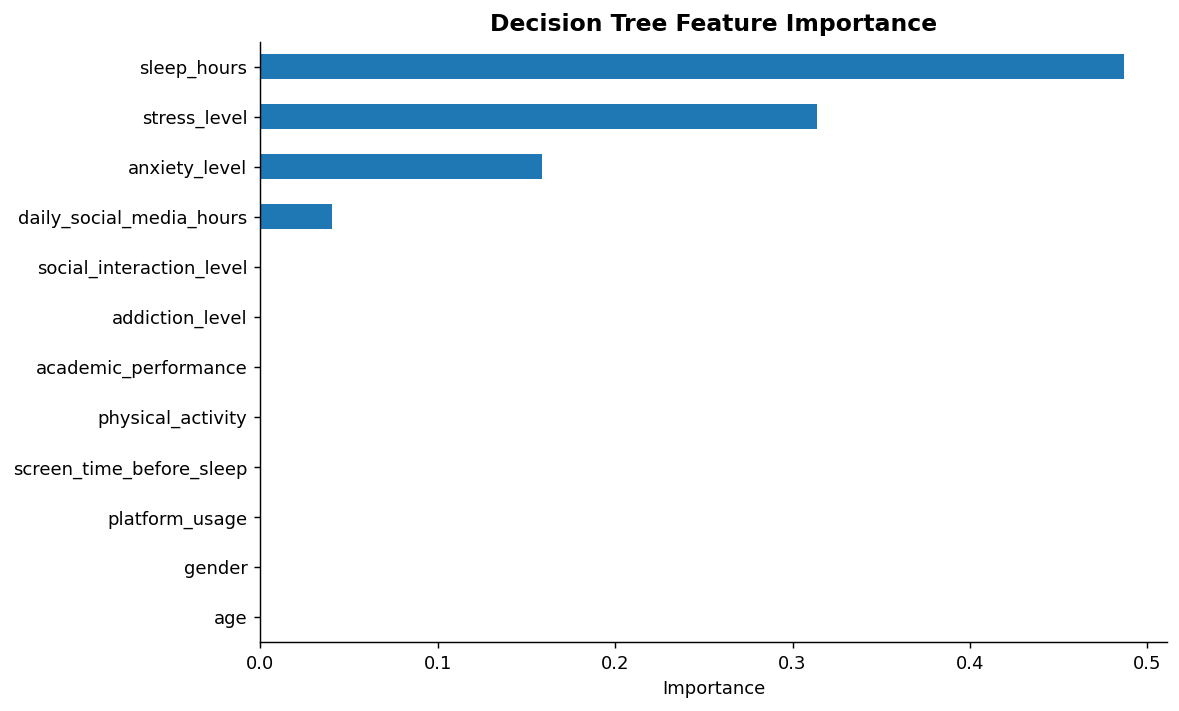

In [16]:
pd.Series(modelD.feature_importances_, index=xtrain.columns).sort_values().plot.barh(
    figsize=(9,6), title='Decision Tree Feature Importance', xlabel='Importance'
)
plt.show()

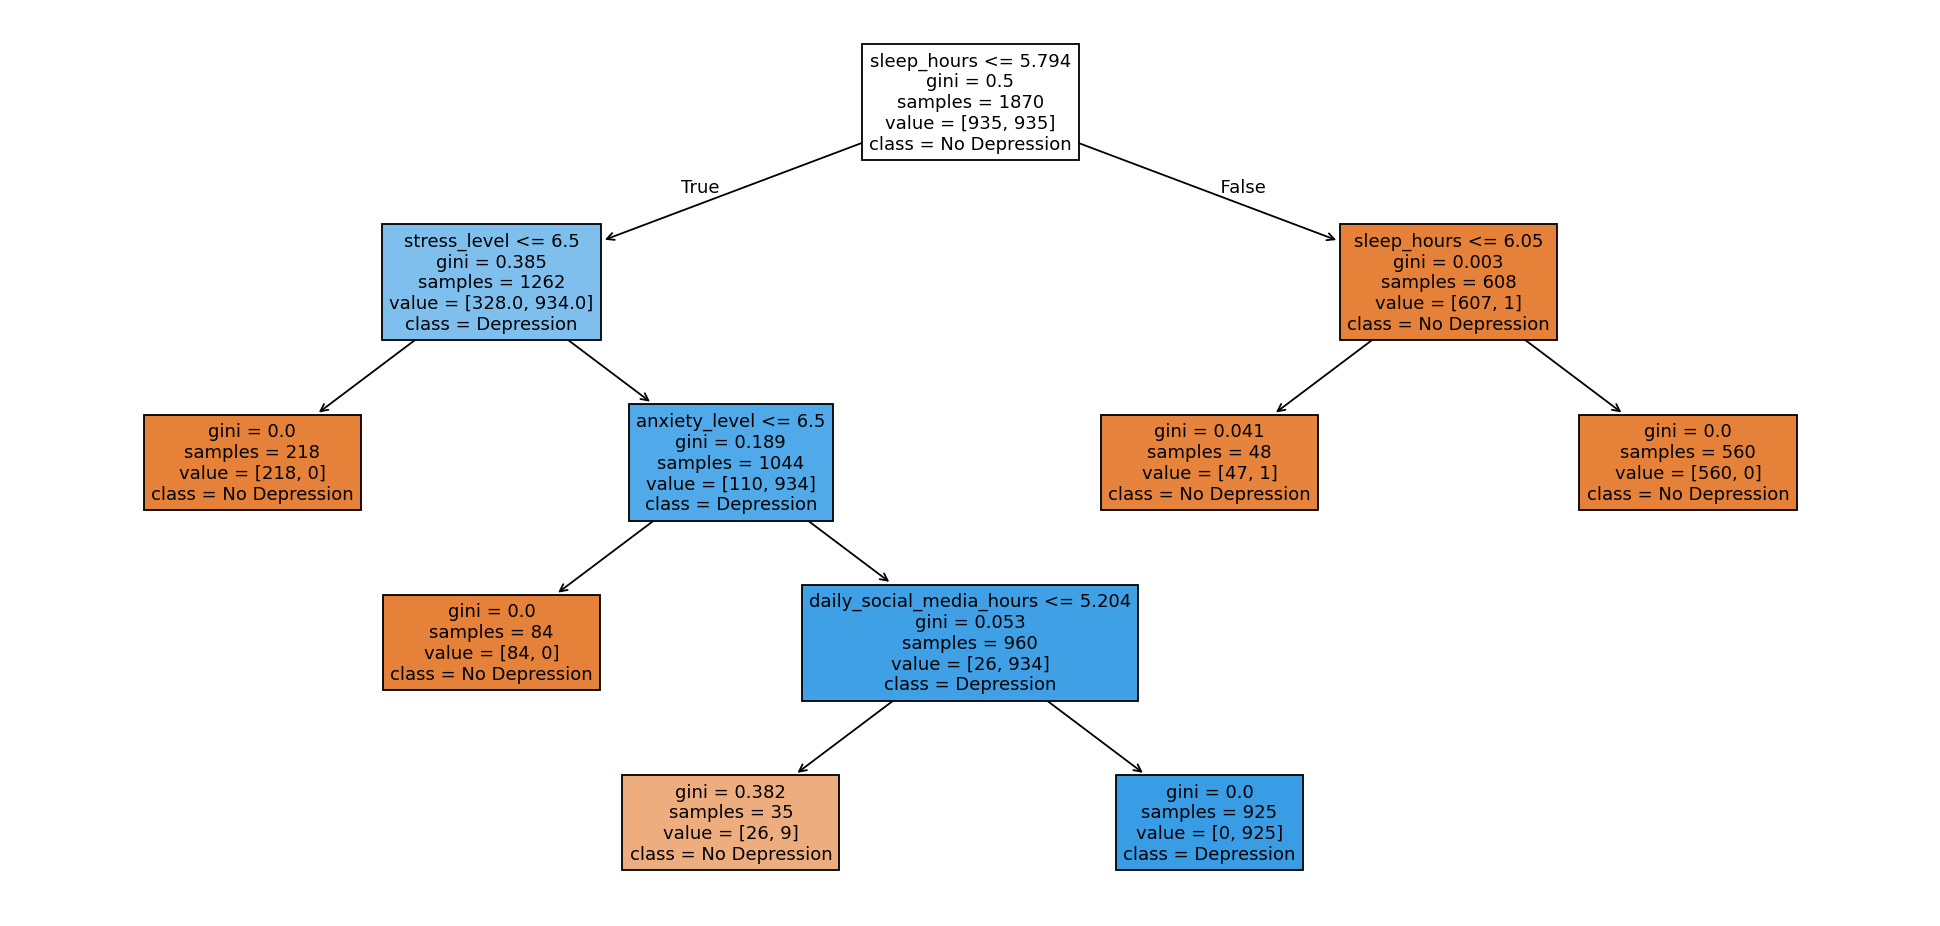

In [17]:
plt.figure(figsize=(19, 9))
plot_tree(modelD,
          max_depth=5,
          feature_names=xtrain.columns,
          class_names=["No Depression", "Depression"],
          filled=True,
          rounded=False,
          fontsize=10)
plt.show()

In [17]:
"""
------------------------


----------------------------


------------------------

"""

'\n------------------------\n\n\n----------------------------\n\n\n------------------------\n\n'

# ****XGB Classifier Model****
* ** **Training the model**
* ** **Predict the answers**
* ** **Cheak The scores**
* ** **Display The Confiosn matrix**
* ** **Display The Features Importince**

 Time := 2.34  seconds


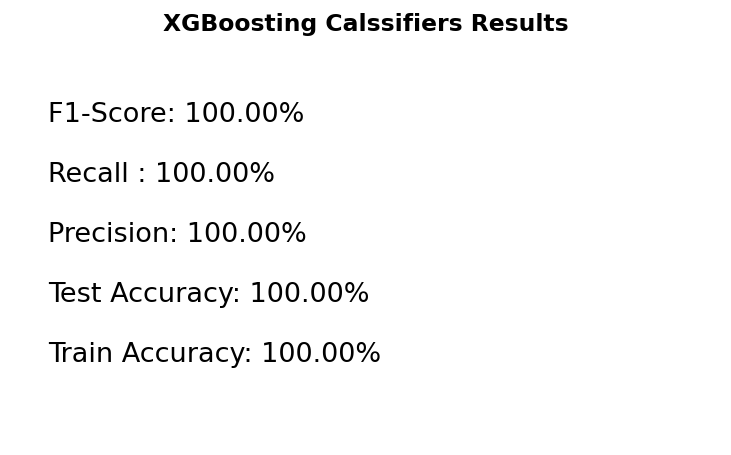

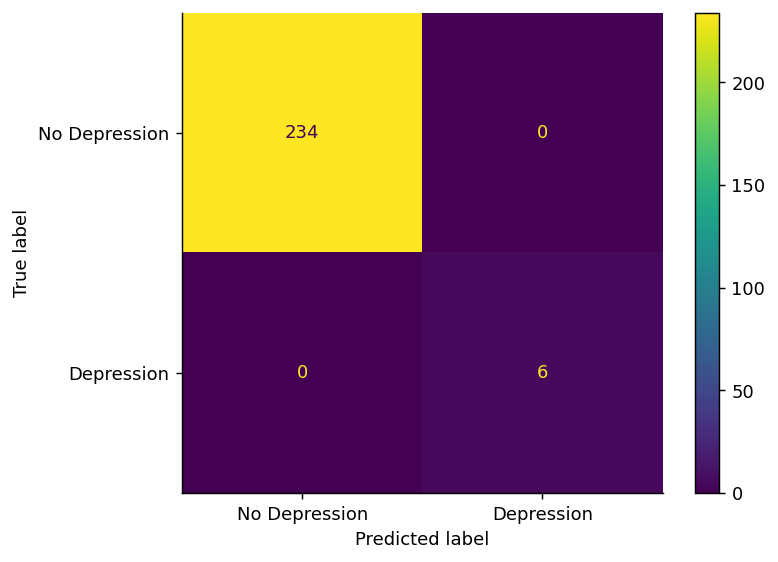

In [18]:
starttime=time.perf_counter()

Best_Grid_Params= {'n_estimators': 500, 'learning_rate': 0.01, 'max_depth': 10,'gamma':0.1}

modelX = XGBClassifier(
    **Best_Grid_Params,
    n_jobs=-1,
    random_state=42
)
""" ==================
"""

modelX.fit(xtrain,ytrain)


train_predictions = modelX.predict(xtrain)
test_predictions =modelX.predict(xtest)


train_Accuracy = accuracy_score(ytrain, train_predictions)
test_Accuracy = accuracy_score(ytest, test_predictions)

Recall = recall_score(ytest, test_predictions)
Precision = precision_score(ytest, test_predictions)
F11 = f1_score(ytest, test_predictions)
cm = confusion_matrix(ytest, test_predictions)


print(' Time :=',format(time.perf_counter()-starttime,'.2f'),' seconds')


plt.figure(figsize=(7,4))
plt.axis('off')
plt.title('XGBoosting Calssifiers Results')
plt.text(0.05, 0.80, f"F1-Score: {F11 * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.65, f"Recall : {Recall * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.50, f"Precision: {Precision * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.35, f"Test Accuracy: {test_Accuracy * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.20, f"Train Accuracy: {train_Accuracy * 100:.2f}%", fontsize=15, ha='left')
plt.show() 
# 82.23,,,,82.29

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Depression", "Depression"]
).plot()

plt.show()

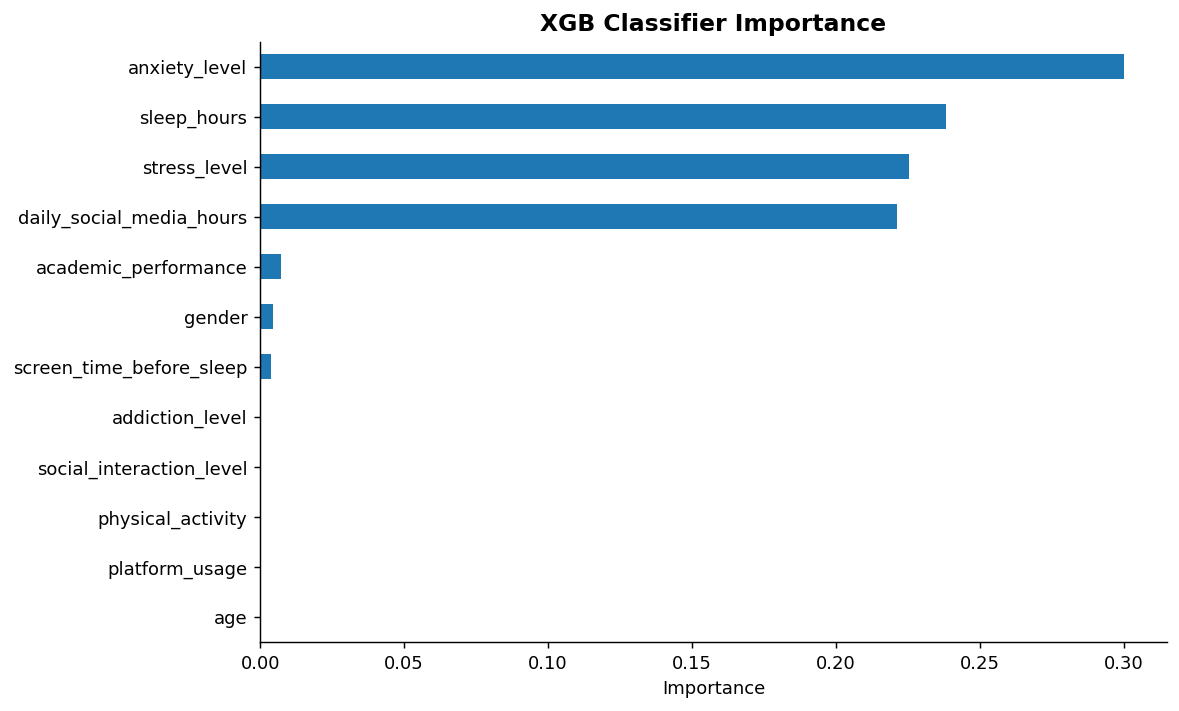

In [19]:
pd.Series(modelX.feature_importances_, index=xtrain.columns).sort_values().plot.barh(
    figsize=(9,6), title='XGB Classifier Importance', xlabel='Importance'
)
plt.show()

In [22]:
param_grid = {
    'max_depth': [5, 8, 11],
    'learning_rate': [0.01, 0.05, 0.1,0.03],
    'n_estimators': [100, 200,300,500],
    # 'scale_pos_weight': [1, 3, 5] 
}
param = {
    "max_depth": [9, 10, 11, 12, 13],
    "learning_rate": [0.05, 0.06, 0.07, 0.08, 0.09],
    "n_estimators": [80, 100, 120, 150]
}
search = GridSearchCV(
        XGBClassifier(random_state=42,n_jobs=1),
        param_grid=param_grid, 
        scoring='f1_macro', 
        cv=5, 
        n_jobs=1
)

# remove '#' to start the search 
# search.fit(xtrain, ytrain)
# print(f"Best Score: {search.best_score_}")
# print(f"Best Params: {search.best_params_}")

# ****Random Forest Classifier Model****
* ** **Training the model using SMOTE training data**
* ** **Predict the answers**
* ** **Cheak The scores**
* ** **Display The Confiosn matrix**
* ** **Display The Features Importince**

 Time := 0.20  seconds


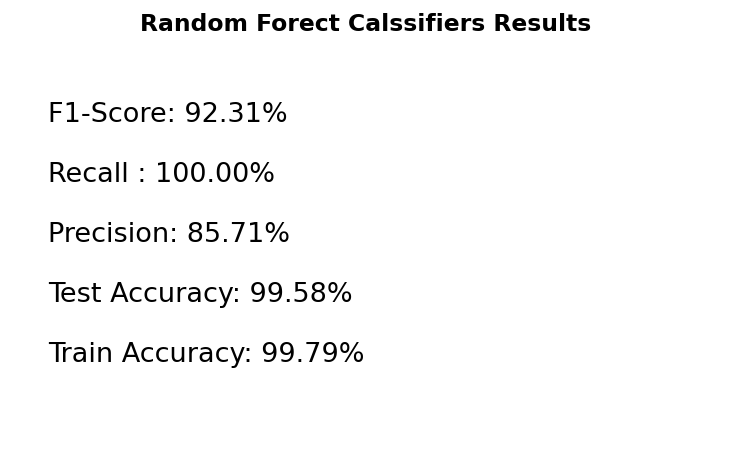

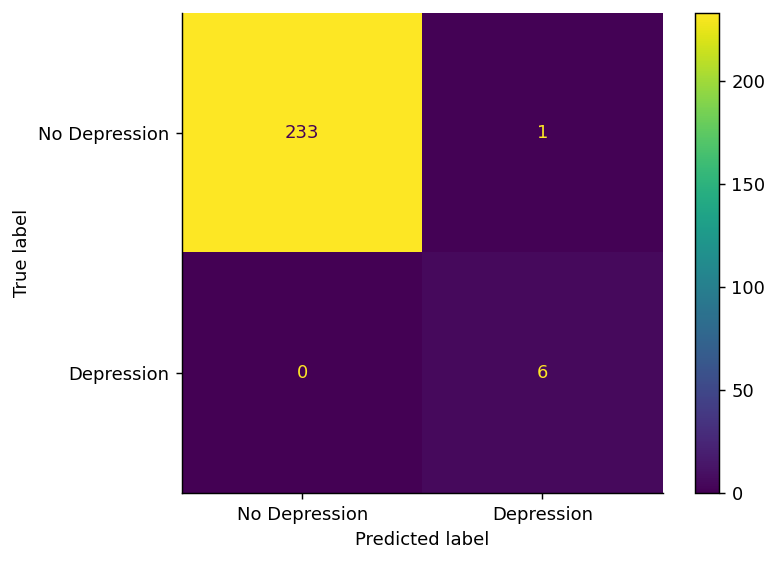

In [23]:
starttime=time.perf_counter()
modelR=RandomForestClassifier(
                              max_depth=3,
                              n_jobs=-1,
                              n_estimators=90,#100
                              max_features='sqrt',
                              random_state=42
    )
"""
 -------------------------
"""
# Train using SMOTE data
modelR.fit(xtrainsmote, ytrainsmote)

# Predictions
train_predictions = modelR.predict(xtrainsmote)
test_predictions = modelR.predict(xtest)



train_Accuracy = accuracy_score(ytrainsmote, train_predictions)
test_Accuracy = accuracy_score(ytest, test_predictions)

Recall = recall_score(ytest, test_predictions)
Precision = precision_score(ytest, test_predictions)
F11 = f1_score(ytest, test_predictions)
cm = confusion_matrix(ytest, test_predictions)




print(' Time :=',format(time.perf_counter()-starttime,'.2f'),' seconds')




# Print the result 
plt.figure(figsize=(7,4))
plt.axis('off')
plt.title('Random Forect Calssifiers Results')
plt.text(0.05, 0.80, f"F1-Score: {F11 * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.65, f"Recall : {Recall * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.50, f"Precision: {Precision * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.35, f"Test Accuracy: {test_Accuracy * 100:.2f}%", fontsize=15, ha='left')
plt.text(0.05, 0.20, f"Train Accuracy: {train_Accuracy * 100:.2f}%", fontsize=15, ha='left')
plt.show() 

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Depression", "Depression"]
).plot()

plt.show()

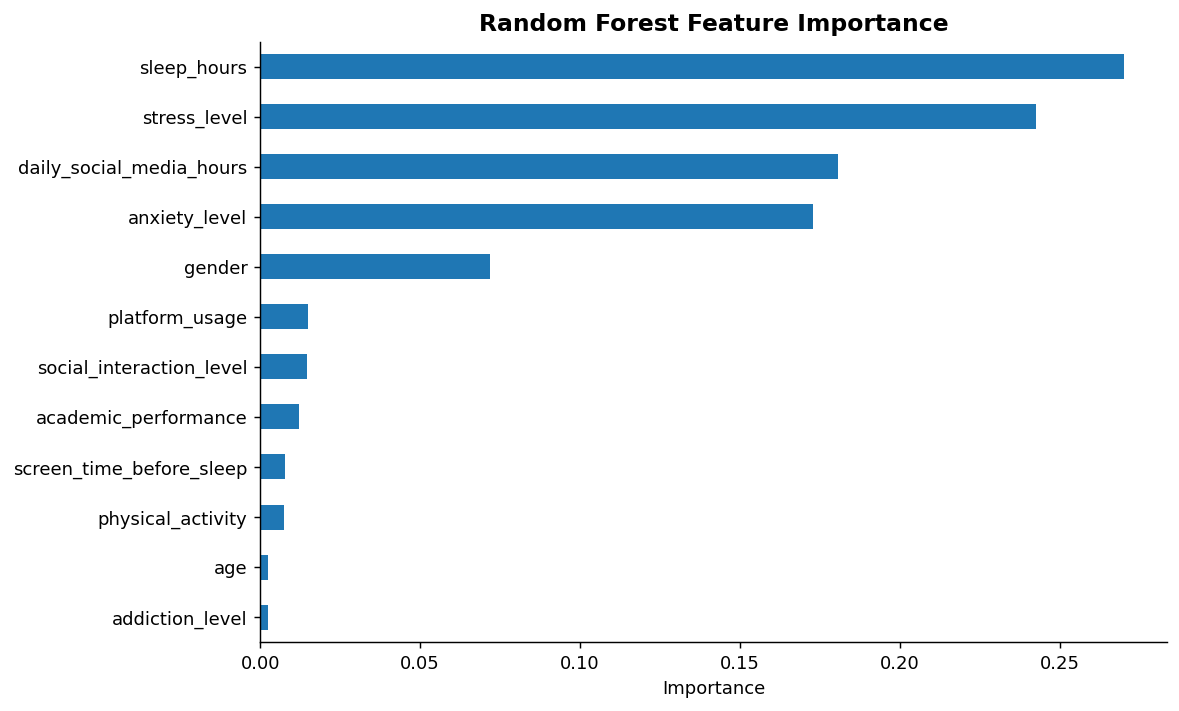

In [24]:
pd.Series(modelR.feature_importances_, index=xtrain.columns).sort_values().plot.barh(
    figsize=(9,6), title='Random Forest Feature Importance', xlabel='Importance'
)
plt.show()

In [25]:
%pip install pickle

ERROR: Could not find a version that satisfies the requirement pickle (from versions: none)
ERROR: No matching distribution found for pickle
Note: you may need to restart the kernel to use updated packages.


In [26]:
# Saving random forest model
import pickle

# Save the model to a file
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(modelR, f)


In [27]:
# Load the model from a file
with open('random_forest_model.pkl', 'rb') as f:
    model = pickle.load(f)

In [30]:
sum(model.predict(xtest)==1)

np.int64(7)